## Dataset Loading and Initial Inspection

In this step, we load the dataset using **pandas** and perform a quick inspection to understand
its structure.

Specifically, we:
- Load the dataset from a CSV file
- Print the number of rows in the dataset
- Display the column names
- Preview the first few rows to verify that the data was loaded correctly


In [1]:
import pandas as pd

# Load the dataset
df = pd.read_csv("data_set.csv")

# Print basic dataset info
print("Number of rows:", len(df))
print("Columns:", df.columns.tolist())

# Display first 3 rows
df.head(3)

Number of rows: 9999
Columns: ['category', 'rating', 'review']


,category,rating,review
0,Toys: Ride-on Toys,4,I was thoroughly impressed with the Rolly Ride...
1,Grocery: Food Gifts & Flowers Shop,1,I had a strongly unpleasant experience with th...
2,Household Essentials: Food Prep Essentials,2,I purchased the Fresh Prep Essential Food Proc...


## Checking Column Data Types

This step inspects the data types of each column in the dataset.
Understanding column types is important to:
- Identify text, numeric, and categorical fields
- Detect potential issues (e.g., numeric values stored as strings)
- Decide which columns need preprocessing or encoding


In [2]:
# Check column data types
df.dtypes

,0
category,object
rating,int64
review,object


## Rating Distribution

This step examines the distribution of the target labels (`rating`) in the dataset.
It helps to:
- Understand how samples are distributed across classes
- Detect class imbalance
- Anticipate potential challenges during training and evaluation


In [3]:
# Check rating distribution
df["rating"].value_counts().sort_index()

,count
rating,
1,2038
2,1956
3,2055
4,1962
5,1988


In [ ]:
## Rating Distribution

This step shows how the ratings are distributed across the dataset and helps
identify possible class imbalance.


In [4]:
# Ensure review column is string
df["review"] = df["review"].astype(str)

# Remove newlines and extra spaces
df["review"] = df["review"].str.replace("\n", " ", regex=False)
df["review"] = df["review"].str.replace("\r", " ", regex=False)
df["review"] = df["review"].str.strip()

# Show one example review
df["review"].iloc[0]

"I was thoroughly impressed with the Rolly Rider, a ride-on toy that brought endless joy to my little one. With its vibrant colors and smooth gliding motion, my child couldn't get enough of it. What really stood out, though, was the fact that it comes with interchangeable wheels, which allowed my child to imagine different scenarios and explore their creativity. The Rolly Rider was a big hit at our family gatherings and playdates - everyone wanted a turn! My only suggestion would be to add some storage for the extra wheels, as my child tends to scatter them around the room. Overall, the Rolly Rider is a top-notch ride-on toy that I would highly recommend to anyone looking for a fun and engaging way to encourage their child's imagination and physical activity."

## Review Length Analysis

This step analyzes the length of each review measured in number of words.
It provides summary statistics to:
- Understand the typical review length
- Identify very short or very long reviews
- Support decisions about maximum sequence length for the model


In [5]:
# Calculate review length in words
df["review_len"] = df["review"].apply(lambda x: len(x.split()))

# Show summary statistics
df["review_len"].describe()


,review_len
count,9999.000000
mean,176.525853
std,30.048386
min,11.000000
25%,156.000000
50%,174.000000
75%,194.000000
max,415.000000


## Review Length Percentiles

This step computes percentiles of review lengths to better understand the
distribution of text sizes in the dataset.

The percentiles help guide the choice of a maximum sequence length by balancing:
- Coverage of most reviews
- Computational efficiency
- Avoiding excessive padding or truncation


In [6]:
import numpy as np

# Print length percentiles to guide max sequence length choice
for p in [50, 75, 90, 95, 99]:
    print(f"P{p}:", int(np.percentile(df["review_len"], p)))


P50: 174
P75: 194
P90: 216
P95: 229
P99: 255


In [7]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 40.3 MB/s eta 0:00:00


## Train / Validation / Test Split

In this step, the dataset is split into training, validation, and test sets
using a stratified sampling strategy based on the target label (`rating`).

The split ratio is:
- 70% Training
- 15% Validation
- 15% Test

Stratification ensures that the class distribution remains consistent across
all splits, enabling reliable training, tuning, and final evaluation.


In [8]:
from sklearn.model_selection import train_test_split

# Load dataset
df = pd.read_csv("data_set.csv")

# Ensure correct data types
df["review"] = df["review"].astype(str)
df["rating"] = df["rating"].astype(int)

# Stratified 70/15/15 split by rating
train_df, temp_df = train_test_split(
    df, test_size=0.30, random_state=42, stratify=df["rating"]
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, random_state=42, stratify=temp_df["rating"]
)

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

Train: 6999
Validation: 1500
Test: 1500


## Tokenization and Vocabulary Construction

In this step, we initialize and train a tokenizer to convert text into integer
sequences.

Key points:
- A fixed vocabulary size of 30,000 words is used
- An out-of-vocabulary (`<OOV>`) token handles unseen words
- The tokenizer is fitted **only on the training set** to avoid data leakage

This process builds a word-to-index mapping that will be used to encode all
text inputs for the model.


In [9]:
from tensorflow.keras.preprocessing.text import Tokenizer

# Vocabulary size
vocab_size = 30000

# Initialize tokenizer
tokenizer = Tokenizer(num_words=vocab_size, oov_token="<OOV>")

# Fit tokenizer on training text only
tokenizer.fit_on_texts(train_df["review"].tolist())

print("Tokenizer vocabulary size:", len(tokenizer.word_index))

Tokenizer vocabulary size: 24024


## Training Word2Vec Embeddings

In this step, we train a **Word2Vec** model on the training reviews to obtain
pretrained word embeddings based on the dataset.

Details:
- Reviews are tokenized into word-level sentences
- Skip-gram architecture is used (`sg=1`)
- Each word is represented by a 128-dimensional vector
- Only words appearing at least twice are included in the vocabulary

These embeddings capture semantic relationships between words and will be used
to initialize the embedding layer in the neural network.


In [10]:
import numpy as np
from gensim.models import Word2Vec

# Prepare tokenized sentences for Word2Vec
train_sentences = [
    text.split() for text in train_df["review"].tolist()
]

# Train Word2Vec model
w2v_model = Word2Vec(
    sentences=train_sentences,
    vector_size=128,
    window=5,
    min_count=2,
    workers=4,
    sg=1  # Skip-gram
)

print("Word2Vec vocabulary size:", len(w2v_model.wv))
print("Word2Vec vector size:", w2v_model.vector_size)

Word2Vec vocabulary size: 26935
Word2Vec vector size: 128


## Building the Embedding Matrix

In this step, we construct an embedding matrix that aligns the Word2Vec
embeddings with the tokenizer vocabulary.

For each word in the tokenizer:
- If the word exists in the Word2Vec model, its pretrained vector is used
- Otherwise, the corresponding embedding remains initialized to zeros

The hit/miss statistics indicate how well the tokenizer vocabulary is covered
by the pretrained embeddings. This matrix will be used to initialize the
embedding layer of the neural network.


In [11]:
# Build embedding matrix aligned with tokenizer vocabulary
embedding_dim = w2v_model.vector_size
embedding_matrix = np.zeros((vocab_size, embedding_dim), dtype=np.float32)

hits = 0
misses = 0

for word, idx in tokenizer.word_index.items():
    if idx >= vocab_size:
        continue
    if word in w2v_model.wv:
        embedding_matrix[idx] = w2v_model.wv[word]
        hits += 1
    else:
        misses += 1

print("Embedding matrix shape:", embedding_matrix.shape)
print("Hits:", hits)
print("Misses:", misses)

Embedding matrix shape: (30000, 128)
Hits: 10953
Misses: 13071


## Text Encoding and Padding

In this step, textual reviews are converted into fixed-length integer sequences
that can be processed by the neural network.

The process includes:
- Converting text into integer sequences using the fitted tokenizer
- Applying padding and truncation to a fixed maximum length
- Using post-padding and post-truncation for consistency
- Converting rating labels from the range 1–5 to 0–4

This ensures that all inputs have uniform shape and are compatible with
sequence-based models.


In [12]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Maximum sequence length (chosen earlier)
max_len = 230

# Convert texts to sequences
train_seq = tokenizer.texts_to_sequences(train_df["review"].tolist())
val_seq   = tokenizer.texts_to_sequences(val_df["review"].tolist())
test_seq  = tokenizer.texts_to_sequences(test_df["review"].tolist())

# Apply padding / truncation
X_train = pad_sequences(train_seq, maxlen=max_len, padding="post", truncating="post")
X_val   = pad_sequences(val_seq,   maxlen=max_len, padding="post", truncating="post")
X_test  = pad_sequences(test_seq,  maxlen=max_len, padding="post", truncating="post")

# Labels: convert from 1–5 to 0–4
y_train = train_df["rating"].values - 1
y_val   = val_df["rating"].values - 1
y_test  = test_df["rating"].values - 1

print(X_train.shape, y_train.shape)
print(X_val.shape, y_val.shape)
print(X_test.shape, y_test.shape)

(6999, 230) (6999,)
(1500, 230) (1500,)
(1500, 230) (1500,)


## SimpleRNN with Frozen Word2Vec Embeddings

In this experiment, we train a SimpleRNN-based classifier initialized with
pretrained Word2Vec embeddings that are kept **frozen** during training.

### Model Architecture
- Embedding layer initialized with pretrained Word2Vec vectors
- Embeddings are frozen to preserve pretrained semantic information
- SimpleRNN layer with 64 hidden units
- Dropout for regularization
- Softmax output layer for 5-class classification

### Training Setup
- Optimizer: Adam
- Loss function: Sparse Categorical Cross-Entropy
- Batch size: 64
- Number of epochs: 8
- Best model checkpoint is saved based on validation loss

### Evaluation
The best model (according to validation loss) is loaded and evaluated on the
test set to obtain the final test accuracy.


In [13]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Embedding, SimpleRNN, Dense, Dropout
from tensorflow.keras.callbacks import ModelCheckpoint

tf.random.set_seed(42)

model_w2v_frozen = Sequential([
    Input(shape=(max_len,)),
    Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim,
        weights=[embedding_matrix],
        trainable=False,
        mask_zero=True
    ),
    SimpleRNN(64),
    Dropout(0.3),
    Dense(5, activation="softmax")
])

model_w2v_frozen.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model_w2v_frozen.summary()

#Save best model during training (but do NOT stop training)
ckpt = ModelCheckpoint(
    filepath="best_w2v_frozen.keras",
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

history_frozen = model_w2v_frozen.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=8,
    batch_size=64,
    verbose=1,
    callbacks=[ckpt]
)

#Load best checkpoint and evaluate on TEST
best_model = tf.keras.models.load_model("best_w2v_frozen.keras")
test_loss_frozen, test_acc_frozen = best_model.evaluate(X_test, y_test, verbose=0)
print("Word2Vec Frozen (BEST VAL) - Test Accuracy:", test_acc_frozen)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 230, 128)       │     3,840,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 64)             │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,852,677 (14.70 MB)

 Trainable params: 12,677 (49.52 KB)

 Non-trainable params: 3,840,000 (14.65 MB)

Epoch 1/8
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.3149 - loss: 1.4869
Epoch 1: val_loss improved from inf to 0.90459, saving model to best_w2v_frozen.keras
110/110 ━━━━━━━━━━━━━━━━━━━━ 9s 53ms/step - accuracy: 0.3157 - loss: 1.4851 - val_accuracy: 0.5787 - val_loss: 0.9046
Epoch 2/8
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.5638 - loss: 0.9680
Epoch 2: val_loss improved from 0.90459 to 0.86639, saving model to best_w2v_frozen.keras
110/110 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.5637 - loss: 0.9681 - val_accuracy: 0.6000 - val_loss: 0.8664
Epoch 3/8
109/110 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.5946 - loss: 0.8241
Epoch 3: val_loss improved from 0.86639 to 0.79931, saving model to best_w2v_frozen.keras
110/110 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.5947 - loss: 0.8235 - val_accuracy: 0.6027 - val_loss: 0.7993
Epoch 4/8
108/110 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.6249 - loss: 0.7456
Epoch 4: val_loss improved from 0.79

## SimpleRNN with Fine-Tuned Word2Vec Embeddings

In this experiment, we use the same SimpleRNN architecture as before, but allow
the Word2Vec embedding layer to be **fine-tuned** during training.

### Key Difference from the Previous Experiment
- The embedding layer is set to `trainable=True`
- Embedding vectors are updated to better adapt to the specific dataset

### Training and Evaluation
The model is trained using the same hyperparameters and checkpointing strategy
as the frozen version. The best checkpoint (based on validation loss) is then
evaluated on the test set to measure final performance.

This comparison helps assess whether fine-tuning pretrained embeddings provides
additional benefits over using them as fixed representations.


In [14]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Embedding, SimpleRNN, Dense, Dropout
from tensorflow.keras.callbacks import ModelCheckpoint

tf.random.set_seed(42)

model_w2v_tuned = Sequential([
    Input(shape=(max_len,)),
    Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim,
        weights=[embedding_matrix],
        trainable=True   # Tuned
        ,
        mask_zero=True
    ),
    SimpleRNN(64),
    Dropout(0.3),
    Dense(5, activation="softmax")
])

model_w2v_tuned.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model_w2v_tuned.summary()

#Save best model (NO stopping)
ckpt = ModelCheckpoint(
    filepath="best_w2v_tuned.keras",
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

history_tuned = model_w2v_tuned.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=8,
    batch_size=64,
    verbose=1,
    callbacks=[ckpt]
)

#Evaluate best checkpoint on TEST
best_model = tf.keras.models.load_model("best_w2v_tuned.keras")
test_loss_tuned, test_acc_tuned = best_model.evaluate(X_test, y_test, verbose=0)
print("Word2Vec Tuned (BEST VAL) - Test Accuracy:", test_acc_tuned)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 230, 128)       │     3,840,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 64)             │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,852,677 (14.70 MB)

 Trainable params: 3,852,677 (14.70 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/8
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.3021 - loss: 1.5239
Epoch 1: val_loss improved from inf to 1.05609, saving model to best_w2v_tuned.keras
110/110 ━━━━━━━━━━━━━━━━━━━━ 9s 56ms/step - accuracy: 0.3028 - loss: 1.5222 - val_accuracy: 0.5433 - val_loss: 1.0561
Epoch 2/8
109/110 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.5629 - loss: 0.9680
Epoch 2: val_loss improved from 1.05609 to 0.79926, saving model to best_w2v_tuned.keras
110/110 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - accuracy: 0.5630 - loss: 0.9675 - val_accuracy: 0.6293 - val_loss: 0.7993
Epoch 3/8
109/110 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.6445 - loss: 0.7488
Epoch 3: val_loss improved from 0.79926 to 0.75871, saving model to best_w2v_tuned.keras
110/110 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.6447 - loss: 0.7483 - val_accuracy: 0.6360 - val_loss: 0.7587
Epoch 4/8
109/110 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.7074 - loss: 0.6435
Epoch 4: val_loss improved from 0.75871

## PyTorch Setup and Reproducibility

This step prepares the environment for training models in **PyTorch**.

It includes:
- Importing core PyTorch modules and evaluation utilities
- Setting random seeds for Python, NumPy, and PyTorch to improve reproducibility
- Enabling deterministic behavior in CuDNN (when using GPU)
- Selecting the training device automatically (`cuda` if available, otherwise `cpu`)

This ensures that experiments are as consistent and comparable as possible.


In [15]:
import random
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pack_padded_sequence
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Reproducibility
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


## PyTorch Dataset and DataLoaders

In this step, we prepare the data for training using PyTorch utilities.

### Custom Dataset
A custom `Dataset` class is defined to:
- Store input sequences and labels as tensors
- Support indexing and length queries required by PyTorch

### Variable-Length Batching
A custom `collate_fn` is used to:
- Stack sequences and labels into batches
- Compute the actual sequence lengths (excluding padding)
- Ensure valid lengths for sequence packing

### DataLoaders
Separate `DataLoader` objects are created for:
- Training (with shuffling)
- Validation
- Testing

This setup enables efficient batching and supports packed sequence processing
for RNN-based models.


In [16]:
class SeqDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.long)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

def collate_with_lengths(batch):
    xs, ys = zip(*batch)
    x = torch.stack(xs, dim=0)  # (B, seq)
    y = torch.stack(ys, dim=0)  # (B,)
    lengths = (x != 0).sum(dim=1)
    lengths = torch.clamp(lengths, min=1)
    return x, y, lengths

batch_size = 64

train_loader = DataLoader(
    SeqDataset(X_train, y_train),
    batch_size=batch_size,
    shuffle=True,
    collate_fn=collate_with_lengths
)

val_loader = DataLoader(
    SeqDataset(X_val, y_val),
    batch_size=batch_size,
    shuffle=False,
    collate_fn=collate_with_lengths
)

test_loader = DataLoader(
    SeqDataset(X_test, y_test),
    batch_size=batch_size,
    shuffle=False,
    collate_fn=collate_with_lengths
)

print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train batches: 110
Val batches: 24
Test batches: 24


## Packed RNN Classifier (PyTorch)

This section defines a flexible sequence-based classifier implemented in
PyTorch, supporting both **GRU** and **LSTM** architectures.

### Model Features
- Embedding layer with optional pretrained initialization
- Support for frozen or fine-tuned embeddings
- GRU or LSTM backend (configurable)
- Optional bidirectional processing
- Dropout for regularization
- Fully connected output layer for multi-class classification

### Variable-Length Sequences
The model uses `pack_padded_sequence` to efficiently process variable-length
inputs, ensuring that padded tokens do not affect the RNN computation.

### Output Representation
- For unidirectional models, the last hidden state is used
- For bidirectional models, forward and backward hidden states are concatenated

This design enables fair and efficient comparison across different RNN
architectures and embedding strategies.


In [17]:
class PackedRNNClassifier(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, num_classes,
                 embedding_matrix=None, rnn_type="gru", dropout=0.3,
                 fine_tune_embeddings=True, bidirectional=False):
        super().__init__()

        self.bidirectional = bidirectional

        # padding_idx=0 مهم جدًا (0 هو padding)
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)

        if embedding_matrix is not None:
            w = torch.tensor(embedding_matrix, dtype=torch.float32)
            self.embedding.weight.data.copy_(w)

        self.embedding.weight.requires_grad = fine_tune_embeddings

        rnn_cls = nn.GRU if rnn_type.lower() == "gru" else nn.LSTM
        self.rnn = rnn_cls(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            batch_first=True,
            bidirectional=bidirectional
        )

        out_dim = hidden_dim * (2 if bidirectional else 1)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(out_dim, num_classes)

    def forward(self, x, lengths):
        emb = self.embedding(x)  # (B, seq, emb)

        packed = pack_padded_sequence(
            emb, lengths.cpu(),
            batch_first=True,
            enforce_sorted=False
        )

        out = self.rnn(packed)

        # GRU: out = (packed_out, h_n)
        # LSTM: out = (packed_out, (h_n, c_n))
        if isinstance(out[1], tuple):
            h_n = out[1][0]  # LSTM h_n
        else:
            h_n = out[1]     # GRU h_n

        # h_n shape: (num_layers*dirs, B, hidden)
        if self.bidirectional:
            h_forward = h_n[-2]   # (B, hidden)
            h_backward = h_n[-1]  # (B, hidden)
            h = torch.cat([h_forward, h_backward], dim=1)  # (B, hidden*2)
        else:
            h = h_n[-1]  # (B, hidden)

        h = self.dropout(h)
        logits = self.fc(h)  # (B, num_classes)
        return logits

## Training and Evaluation Utilities (PyTorch)

This section defines the core utilities used to train and evaluate the PyTorch
sequence models.

### Evaluation (`evaluate`)
- Runs the model in evaluation mode with gradients disabled (`@torch.no_grad()`)
- Computes average loss and accuracy over a given data loader
- Collects predicted labels and true labels for later analysis (e.g., confusion matrix)

### Training Loop (`train_model`)
- Trains the model for a fixed number of epochs using:
  - Loss: Cross-Entropy Loss (multi-class classification)
  - Optimizer: Adam (only updates parameters with `requires_grad=True`)
  - Weight decay for regularization
- Tracks and stores training/validation loss and accuracy each epoch
- Saves the best model checkpoint based on **lowest validation loss**
- Restores the best checkpoint at the end to ensure final model quality


In [18]:
@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, total_n = 0.0, 0
    all_preds, all_true = [], []

    for x, y, lengths in loader:
        x, y, lengths = x.to(device), y.to(device), lengths.to(device)

        logits = model(x, lengths)
        loss = criterion(logits, y)

        bs = y.size(0)
        total_loss += loss.item() * bs
        total_n += bs

        preds = torch.argmax(logits, dim=1)
        all_preds.append(preds.cpu().numpy())
        all_true.append(y.cpu().numpy())

    y_pred = np.concatenate(all_preds)
    y_true = np.concatenate(all_true)
    acc = accuracy_score(y_true, y_pred)
    return total_loss / total_n, acc, y_true, y_pred


def train_model(model, train_loader, val_loader, epochs=12, lr=1e-3, save_path="best_model.pt"):
    model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr, weight_decay=1e-4)

    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

    best_val_loss = float("inf")
    best_state = None

    for ep in range(1, epochs + 1):
        model.train()
        total_loss, total_n = 0.0, 0
        all_preds, all_true = [], []

        for x, y, lengths in train_loader:
            x, y, lengths = x.to(device), y.to(device), lengths.to(device)

            optimizer.zero_grad()
            logits = model(x, lengths)
            loss = criterion(logits, y)
            loss.backward()
            optimizer.step()

            bs = y.size(0)
            total_loss += loss.item() * bs
            total_n += bs

            preds = torch.argmax(logits, dim=1)
            all_preds.append(preds.detach().cpu().numpy())
            all_true.append(y.detach().cpu().numpy())

        train_loss = total_loss / total_n
        train_acc = accuracy_score(np.concatenate(all_true), np.concatenate(all_preds))

        val_loss, val_acc, _, _ = evaluate(model, val_loader, criterion)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        print(f"Epoch {ep:02d}/{epochs} | Train Loss={train_loss:.4f} Acc={train_acc:.4f} | Val Loss={val_loss:.4f} Acc={val_acc:.4f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            torch.save(best_state, save_path)
            print(f"Saved best to: {save_path}")

    # restore best
    if best_state is not None:
        model.load_state_dict(best_state)

    return history

## Fix: Rebuilding DataLoaders with Sequence Lengths

This cell applies a critical fix to the PyTorch input pipeline by rebuilding the
DataLoaders to return **three items per batch**: `(x, y, lengths)`.

### Why This Fix Is Needed
Packed sequence models (using `pack_padded_sequence`) require the true lengths of
each sequence in the batch. Without lengths, the model cannot correctly ignore
padding tokens during the RNN computation.

### What This Cell Does
- Re-defines a simple `Dataset` that returns `(sequence, label)`
- Implements a custom `collate_fn` that:
  - stacks samples into tensors
  - computes sequence lengths by counting non-zero (non-padding) tokens
  - ensures all lengths are at least 1
- Rebuilds train/validation/test DataLoaders using this collate function

### Sanity Check
A small batch is sampled to verify that the loader outputs exactly:
- `x` (batch of sequences)
- `y` (batch of labels)
- `lengths` (batch of sequence lengths)


In [19]:
# =========================
# FIX: rebuild PyTorch loaders to return (x, y, lengths)
# =========================

import torch
from torch.utils.data import Dataset, DataLoader

class SeqDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.long)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

def collate_with_lengths(batch):
    xs, ys = zip(*batch)
    x = torch.stack(xs, dim=0)
    y = torch.stack(ys, dim=0)
    lengths = (x != 0).sum(dim=1)
    lengths = torch.clamp(lengths, min=1)
    return x, y, lengths

batch_size = 64

train_loader = DataLoader(
    SeqDataset(X_train, y_train),
    batch_size=batch_size,
    shuffle=True,
    collate_fn=collate_with_lengths
)

val_loader = DataLoader(
    SeqDataset(X_val, y_val),
    batch_size=batch_size,
    shuffle=False,
    collate_fn=collate_with_lengths
)

test_loader = DataLoader(
    SeqDataset(X_test, y_test),
    batch_size=batch_size,
    shuffle=False,
    collate_fn=collate_with_lengths
)

print("Rebuilt loaders with lengths:")
print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))
print("Test batches:", len(test_loader))

# Quick check (must print 3 items)
xb, yb, lb = next(iter(train_loader))
print("Batch shapes:", xb.shape, yb.shape, lb.shape)


Rebuilt loaders with lengths:
Train batches: 110
Val batches: 24
Test batches: 24
Batch shapes: torch.Size([64, 230]) torch.Size([64]) torch.Size([64])


## Experiment: GRU (Packed) with Fine-Tuned Word2Vec Embeddings

In this experiment, we train a **unidirectional GRU** classifier in PyTorch using
packed sequences for efficient handling of variable-length inputs.

### Configuration
- Model: GRU (packed sequence processing)
- Hidden size: 64
- Dropout: 0.3
- Embeddings: Word2Vec-initialized and **fine-tuned** (`fine_tune_embeddings=True`)
- Output: 5-class softmax classification (implemented via CrossEntropyLoss)

### Training
The model is trained for 12 epochs using:
- Optimizer: Adam
- Learning rate: 1e-3
- Best checkpoint saved based on validation loss (`best_gru_tuned_pt.pt`)

### Final Test Evaluation
After training, we load the best validation checkpoint and evaluate on the test set.
We report:
- Test loss and accuracy
- Confusion matrix
- Full classification report (precision, recall, F1-score per class)


In [20]:
hidden_dim = 64
num_classes = 5

model_gru_tuned_pt = PackedRNNClassifier(
    vocab_size=vocab_size,
    embedding_dim=embedding_dim,
    hidden_dim=hidden_dim,
    num_classes=num_classes,
    embedding_matrix=embedding_matrix,
    rnn_type="gru",
    dropout=0.3,
    fine_tune_embeddings=True,   # tuned
    bidirectional=False          # GRU normal
)

history_gru_tuned_pt = train_model(
    model_gru_tuned_pt,
    train_loader,
    val_loader,
    epochs=12,
    lr=1e-3,
    save_path="best_gru_tuned_pt.pt"
)

# Load best and TEST
best_state = torch.load("best_gru_tuned_pt.pt", map_location="cpu")
model_gru_tuned_pt.load_state_dict(best_state)
model_gru_tuned_pt.to(device)

criterion = nn.CrossEntropyLoss()
test_loss, test_acc, y_true, y_pred = evaluate(model_gru_tuned_pt, test_loader, criterion)

print("\n" + "="*70)
print("PyTorch GRU Tuned (PACKED) - FINAL TEST")
print("="*70)
print("Test Accuracy:", round(test_acc, 4))
print("Test Loss:", round(test_loss, 4))
print("\nConfusion Matrix:\n", confusion_matrix(y_true, y_pred))
print("\nClassification Report:\n", classification_report(y_true, y_pred, digits=4))


Epoch 01/12 | Train Loss=1.1659 Acc=0.4646 | Val Loss=0.7137 Acc=0.6473
Saved best to: best_gru_tuned_pt.pt
Epoch 02/12 | Train Loss=0.6617 Acc=0.6434 | Val Loss=0.6530 Acc=0.6540
Saved best to: best_gru_tuned_pt.pt
Epoch 03/12 | Train Loss=0.5754 Acc=0.7048 | Val Loss=0.5528 Acc=0.7013
Saved best to: best_gru_tuned_pt.pt
Epoch 04/12 | Train Loss=0.4976 Acc=0.7461 | Val Loss=0.5214 Acc=0.7193
Saved best to: best_gru_tuned_pt.pt
Epoch 05/12 | Train Loss=0.4601 Acc=0.7978 | Val Loss=0.3562 Acc=0.8267
Saved best to: best_gru_tuned_pt.pt
Epoch 06/12 | Train Loss=0.2564 Acc=0.8978 | Val Loss=0.3207 Acc=0.8867
Saved best to: best_gru_tuned_pt.pt
Epoch 07/12 | Train Loss=0.1699 Acc=0.9444 | Val Loss=0.1489 Acc=0.9540
Saved best to: best_gru_tuned_pt.pt
Epoch 08/12 | Train Loss=0.1040 Acc=0.9701 | Val Loss=0.1014 Acc=0.9747
Saved best to: best_gru_tuned_pt.pt
Epoch 09/12 | Train Loss=0.0627 Acc=0.9826 | Val Loss=0.1132 Acc=0.9640
Epoch 10/12 | Train Loss=0.0370 Acc=0.9916 | Val Loss=0.0921 Acc

## Experiment: LSTM (Packed) with Fine-Tuned Word2Vec Embeddings

In this experiment, we train a **unidirectional LSTM** classifier in PyTorch
using packed sequences to properly handle variable-length inputs and ignore padding.

### Configuration
- Model: LSTM (packed sequence processing)
- Hidden size: 64
- Dropout: 0.3
- Embeddings: Word2Vec-initialized and **fine-tuned** (`fine_tune_embeddings=True`)
- Output: 5-class classification (CrossEntropyLoss)

### Training
The model is trained for 12 epochs with:
- Optimizer: Adam
- Learning rate: 1e-3
- Best checkpoint saved based on validation loss (`best_lstm_tuned_pt.pt`)

### Final Test Evaluation
After training, the best validation checkpoint is loaded and evaluated on the test set.
We report:
- Test loss and accuracy
- Confusion matrix
- Classification report (precision, recall, F1-score per class)


In [21]:
model_lstm_tuned_pt = PackedRNNClassifier(
    vocab_size=vocab_size,
    embedding_dim=embedding_dim,
    hidden_dim=hidden_dim,
    num_classes=num_classes,
    embedding_matrix=embedding_matrix,
    rnn_type="lstm",
    dropout=0.3,
    fine_tune_embeddings=True,   # tuned
    bidirectional=False
)

history_lstm_tuned_pt = train_model(
    model_lstm_tuned_pt,
    train_loader,
    val_loader,
    epochs=12,
    lr=1e-3,
    save_path="best_lstm_tuned_pt.pt"
)

best_state = torch.load("best_lstm_tuned_pt.pt", map_location="cpu")
model_lstm_tuned_pt.load_state_dict(best_state)
model_lstm_tuned_pt.to(device)

criterion = nn.CrossEntropyLoss()
test_loss, test_acc, y_true, y_pred = evaluate(model_lstm_tuned_pt, test_loader, criterion)

print("\n" + "="*70)
print("✅ PyTorch LSTM Tuned (PACKED) - FINAL TEST")
print("="*70)
print("Test Accuracy:", round(test_acc, 4))
print("Test Loss:", round(test_loss, 4))
print("\nConfusion Matrix:\n", confusion_matrix(y_true, y_pred))
print("\nClassification Report:\n", classification_report(y_true, y_pred, digits=4))

Epoch 01/12 | Train Loss=1.2307 Acc=0.4479 | Val Loss=0.7807 Acc=0.6187
Saved best to: best_lstm_tuned_pt.pt
Epoch 02/12 | Train Loss=0.7385 Acc=0.6198 | Val Loss=0.6668 Acc=0.6433
Saved best to: best_lstm_tuned_pt.pt
Epoch 03/12 | Train Loss=0.6776 Acc=0.6562 | Val Loss=0.6302 Acc=0.6720
Saved best to: best_lstm_tuned_pt.pt
Epoch 04/12 | Train Loss=0.5617 Acc=0.7158 | Val Loss=0.6264 Acc=0.7000
Saved best to: best_lstm_tuned_pt.pt
Epoch 05/12 | Train Loss=0.5035 Acc=0.7613 | Val Loss=0.5622 Acc=0.7300
Saved best to: best_lstm_tuned_pt.pt
Epoch 06/12 | Train Loss=0.4411 Acc=0.8104 | Val Loss=0.5557 Acc=0.7540
Saved best to: best_lstm_tuned_pt.pt
Epoch 07/12 | Train Loss=0.4063 Acc=0.8311 | Val Loss=0.4626 Acc=0.7947
Saved best to: best_lstm_tuned_pt.pt
Epoch 08/12 | Train Loss=0.3586 Acc=0.8613 | Val Loss=0.4914 Acc=0.7873
Epoch 09/12 | Train Loss=0.2634 Acc=0.9040 | Val Loss=0.4607 Acc=0.8013
Saved best to: best_lstm_tuned_pt.pt
Epoch 10/12 | Train Loss=0.2344 Acc=0.9174 | Val Loss=0.

## Experiment: BiLSTM (Packed) with Fine-Tuned Word2Vec Embeddings

In this experiment, we train a **bidirectional LSTM (BiLSTM)** classifier in PyTorch
using packed sequences to fully leverage context from both past and future tokens.

### Configuration
- Model: Bidirectional LSTM (packed sequence processing)
- Hidden size: 64 (per direction)
- Dropout: 0.3
- Embeddings: Word2Vec-initialized and **fine-tuned**
- Output dimension: Concatenation of forward and backward hidden states
- Task: 5-class text classification

### Training
The model is trained for 12 epochs with:
- Optimizer: Adam
- Learning rate: 1e-3
- Best checkpoint selected based on validation loss (`best_bilstm_tuned_pt.pt`)

### Final Test Evaluation
After training, the best validation checkpoint is loaded and evaluated on the test set.
Reported metrics include:
- Test loss and accuracy
- Confusion matrix
- Detailed classification report (precision, recall, F1-score)

This experiment evaluates whether bidirectional context improves performance
over unidirectional LSTM and GRU models.


In [22]:
model_bilstm_tuned_pt = PackedRNNClassifier(
    vocab_size=vocab_size,
    embedding_dim=embedding_dim,
    hidden_dim=hidden_dim,
    num_classes=num_classes,
    embedding_matrix=embedding_matrix,
    rnn_type="lstm",
    dropout=0.3,
    fine_tune_embeddings=True,
    bidirectional=True
)

history_bilstm_tuned_pt = train_model(
    model_bilstm_tuned_pt,
    train_loader,
    val_loader,
    epochs=12,
    lr=1e-3,
    save_path="best_bilstm_tuned_pt.pt"
)

best_state = torch.load("best_lstm_tuned_pt.pt", map_location="cpu")
model_lstm_tuned_pt.load_state_dict(best_state)
model_lstm_tuned_pt.to(device)

criterion = nn.CrossEntropyLoss()
test_loss, test_acc, y_true, y_pred = evaluate(model_lstm_tuned_pt, test_loader, criterion)

print("\n" + "="*70)
print("PyTorch BILSTM Tuned (PACKED) - FINAL TEST")
print("="*70)
print("Test Accuracy:", round(test_acc, 4))
print("Test Loss:", round(test_loss, 4))
print("\nConfusion Matrix:\n", confusion_matrix(y_true, y_pred))
print("\nClassification Report:\n", classification_report(y_true, y_pred, digits=4))

Epoch 01/12 | Train Loss=0.7624 Acc=0.7630 | Val Loss=0.1955 Acc=0.9420
Saved best to: best_bilstm_tuned_pt.pt
Epoch 02/12 | Train Loss=0.1864 Acc=0.9387 | Val Loss=0.1128 Acc=0.9687
Saved best to: best_bilstm_tuned_pt.pt
Epoch 03/12 | Train Loss=0.1209 Acc=0.9607 | Val Loss=0.1673 Acc=0.9520
Epoch 04/12 | Train Loss=0.0965 Acc=0.9716 | Val Loss=0.1029 Acc=0.9653
Saved best to: best_bilstm_tuned_pt.pt
Epoch 05/12 | Train Loss=0.0639 Acc=0.9806 | Val Loss=0.1164 Acc=0.9607
Epoch 06/12 | Train Loss=0.0518 Acc=0.9860 | Val Loss=0.0991 Acc=0.9660
Saved best to: best_bilstm_tuned_pt.pt
Epoch 07/12 | Train Loss=0.0336 Acc=0.9909 | Val Loss=0.1102 Acc=0.9647
Epoch 08/12 | Train Loss=0.0314 Acc=0.9921 | Val Loss=0.1276 Acc=0.9620
Epoch 09/12 | Train Loss=0.0274 Acc=0.9926 | Val Loss=0.1307 Acc=0.9593
Epoch 10/12 | Train Loss=0.0343 Acc=0.9917 | Val Loss=0.1153 Acc=0.9680
Epoch 11/12 | Train Loss=0.0152 Acc=0.9964 | Val Loss=0.1630 Acc=0.9600
Epoch 12/12 | Train Loss=0.0288 Acc=0.9930 | Val Los

## Experiment: BiGRU (Packed) with Fine-Tuned Word2Vec Embeddings

In this experiment, we train a **bidirectional GRU (BiGRU)** classifier in PyTorch
using packed sequences to handle variable-length inputs while ignoring padding.

### Configuration
- Model: Bidirectional GRU (packed sequence processing)
- Hidden size: 64 (per direction)
- Dropout: 0.3
- Embeddings: Word2Vec-initialized and **fine-tuned**
- Output: Concatenation of forward and backward hidden states for classification
- Task: 5-class text classification

### Training
The model is trained for 12 epochs with:
- Optimizer: Adam
- Learning rate: 1e-3
- Best checkpoint saved based on validation loss (`best_bigru_tuned_pt.pt`)

### Final Test Evaluation
After training, the best checkpoint is loaded and evaluated on the test set.
We report:
- Test loss and accuracy
- Confusion matrix
- Full classification report (precision, recall, F1-score per class)

This experiment tests whether bidirectional context improves performance compared
to the unidirectional GRU model.


In [23]:
hidden_dim = 64
num_classes = 5

model_bigru_tuned_pt = PackedRNNClassifier(
    vocab_size=vocab_size,
    embedding_dim=embedding_dim,
    hidden_dim=hidden_dim,
    num_classes=num_classes,
    embedding_matrix=embedding_matrix,
    rnn_type="gru",
    dropout=0.3,
    fine_tune_embeddings=True,   # tuned
    bidirectional=True
)

history_bigru_tuned_pt = train_model(
    model_bigru_tuned_pt,
    train_loader,
    val_loader,
    epochs=12,
    lr=1e-3,
    save_path="best_bigru_tuned_pt.pt"
)

# Load best and TEST
best_state = torch.load("best_gru_tuned_pt.pt", map_location="cpu")
model_gru_tuned_pt.load_state_dict(best_state)
model_gru_tuned_pt.to(device)

criterion = nn.CrossEntropyLoss()
test_loss, test_acc, y_true, y_pred = evaluate(model_gru_tuned_pt, test_loader, criterion)

print("\n" + "="*70)
print("PyTorch BIGRU Tuned (PACKED) - FINAL TEST")
print("="*70)
print("Test Accuracy:", round(test_acc, 4))
print("Test Loss:", round(test_loss, 4))
print("\nConfusion Matrix:\n", confusion_matrix(y_true, y_pred))
print("\nClassification Report:\n", classification_report(y_true, y_pred, digits=4))


Epoch 01/12 | Train Loss=0.8060 Acc=0.7285 | Val Loss=0.3398 Acc=0.8773
Saved best to: best_bigru_tuned_pt.pt
Epoch 02/12 | Train Loss=0.2080 Acc=0.9290 | Val Loss=0.1377 Acc=0.9527
Saved best to: best_bigru_tuned_pt.pt
Epoch 03/12 | Train Loss=0.1042 Acc=0.9680 | Val Loss=0.1099 Acc=0.9620
Saved best to: best_bigru_tuned_pt.pt
Epoch 04/12 | Train Loss=0.0802 Acc=0.9774 | Val Loss=0.0966 Acc=0.9633
Saved best to: best_bigru_tuned_pt.pt
Epoch 05/12 | Train Loss=0.0473 Acc=0.9886 | Val Loss=0.0965 Acc=0.9640
Saved best to: best_bigru_tuned_pt.pt
Epoch 06/12 | Train Loss=0.0299 Acc=0.9934 | Val Loss=0.0943 Acc=0.9667
Saved best to: best_bigru_tuned_pt.pt
Epoch 07/12 | Train Loss=0.0274 Acc=0.9930 | Val Loss=0.1115 Acc=0.9653
Epoch 08/12 | Train Loss=0.0302 Acc=0.9939 | Val Loss=0.1230 Acc=0.9620
Epoch 09/12 | Train Loss=0.0119 Acc=0.9984 | Val Loss=0.1018 Acc=0.9700
Epoch 10/12 | Train Loss=0.0116 Acc=0.9981 | Val Loss=0.1174 Acc=0.9707
Epoch 11/12 | Train Loss=0.0215 Acc=0.9931 | Val Los

## Packed Model Evaluation and Reporting

This section defines helper functions to evaluate packed-sequence PyTorch models
and produce detailed classification metrics.

### Prediction (`predict_all_packed`)
- Runs inference in evaluation mode with gradients disabled (`@torch.no_grad()`)
- Iterates over a loader that returns `(x, y, lengths)`
- Computes class predictions using `argmax` over logits
- Returns concatenated arrays of predictions and true labels

### Evaluation Summary (`evaluate_and_print_packed`)
Given model predictions, this function computes and prints:
- Accuracy
- Precision / Recall / F1-score (macro)
- Precision / Recall / F1-score (weighted)
- Confusion matrix
- Full classification report per class

It also returns a compact dictionary of key metrics (accuracy, macro F1,
weighted F1, and confusion matrix) for easier comparison across experiments.


In [24]:
import numpy as np
import torch

from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    confusion_matrix, classification_report
)

@torch.no_grad()
def predict_all_packed(model, loader, device):
    model.eval()
    all_preds = []
    all_labels = []

    for x, y, lengths in loader:
        x = x.to(device)
        y = y.to(device)
        lengths = lengths.to(device)

        logits = model(x, lengths)
        preds = torch.argmax(logits, dim=1)

        all_preds.append(preds.cpu().numpy())
        all_labels.append(y.cpu().numpy())

    return np.concatenate(all_preds), np.concatenate(all_labels)


def evaluate_and_print_packed(model, loader, device, title=""):
    y_pred, y_true = predict_all_packed(model, loader, device)

    acc = accuracy_score(y_true, y_pred)

    p_macro, r_macro, f_macro, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0
    )
    p_weighted, r_weighted, f_weighted, _ = precision_recall_fscore_support(
        y_true, y_pred, average="weighted", zero_division=0
    )

    cm = confusion_matrix(y_true, y_pred)

    print("="*60)
    if title:
        print(title)
    print("Accuracy:", acc)
    print("Precision (macro):", p_macro)
    print("Recall    (macro):", r_macro)
    print("F1        (macro):", f_macro)
    print("Precision (weighted):", p_weighted)
    print("Recall    (weighted):", r_weighted)
    print("F1        (weighted):", f_weighted)

    print("\nConfusion Matrix:\n", cm)
    print("\nClassification Report:\n",
          classification_report(y_true, y_pred, digits=4, zero_division=0))
    print("="*60)

    return {
        "acc": acc,
        "f1_macro": f_macro,
        "f1_weighted": f_weighted,
        "cm": cm
    }

In [ ]:
## Validation Comparison of Packed RNN Models

This section evaluates and compares multiple **packed-sequence RNN models** on
the validation set using the same evaluation protocol.

### Models Evaluated
- **LSTM (Unidirectional)** – Packed sequence processing
- **GRU (Unidirectional)** – Packed sequence processing
- **BiLSTM** – Bidirectional LSTM with packed sequences
- **BiGRU** – Bidirectional GRU with packed sequences

### Evaluation Metrics
For each model, we report:
- Accuracy
- Macro-averaged Precision, Recall, and F1-score
- Weighted Precision, Recall, and F1-score
- Confusion Matrix
- Full per-class Classification Report

Using a consistent validation set allows fair comparison between architectures
and helps guide the selection of the best-performing model for final testing.


In [25]:
lstm_uni_val = evaluate_and_print_packed(
    model_lstm_tuned_pt,   # bidirectional=False
    val_loader,
    device,
    title="LSTM Uni-directional (Packed) - Validation"
)

gru_uni_val = evaluate_and_print_packed(
    model_gru_tuned_pt,    # bidirectional=False
    val_loader,
    device,
    title="GRU Uni-directional (Packed) - Validation"
)

bilstm_val = evaluate_and_print_packed(
    model_lstm_tuned_pt,
    val_loader,
    device,
    title="BILSTM (Packed) - Validation"
)

bigru_val = evaluate_and_print_packed(
    model_gru_tuned_pt,
    val_loader,
    device,
    title="BIGRU (Packed) - Validation"
)


LSTM Uni-directional (Packed) - Validation
Accuracy: 0.8013333333333333
Precision (macro): 0.8005009181759416
Recall    (macro): 0.8001005343256293
F1        (macro): 0.8000349993166337
Precision (weighted): 0.8015668001637002
Recall    (weighted): 0.8013333333333333
F1        (weighted): 0.8011871442702595

Confusion Matrix:
 [[231  73   1   0   0]
 [ 78 207   9   0   0]
 [  1   6 297   2   2]
 [  0   0   0 224  71]
 [  0   0   0  55 243]]

Classification Report:
               precision    recall  f1-score   support

           0     0.7452    0.7574    0.7512       305
           1     0.7238    0.7041    0.7138       294
           2     0.9674    0.9643    0.9659       308
           3     0.7972    0.7593    0.7778       295
           4     0.7690    0.8154    0.7915       298

    accuracy                         0.8013      1500
   macro avg     0.8005    0.8001    0.8000      1500
weighted avg     0.8016    0.8013    0.8012      1500

GRU Uni-directional (Packed) - Validation

## Visualization, Evaluation, and Error Analysis Utilities (PyTorch)

This cell defines reusable helper functions to analyze model performance across
training and evaluation stages.

### Training Curves (`plot_history_torch`)
Plots training vs. validation trends over epochs for:
- Loss (train vs. validation)
- Accuracy (train vs. validation)

These plots help detect underfitting/overfitting and evaluate training stability.

### Packed-Sequence Prediction (`predict_all_packed`)
Runs inference on DataLoaders that return `(x, y, lengths)` and calls the model as
`model(x, lengths)`. Predictions are collected and returned alongside true labels.

### Evaluation Report (`evaluate_and_print_packed`)
Computes and prints a comprehensive performance summary:
- Accuracy
- Macro F1-score (treats all classes equally)
- Weighted F1-score (accounts for class support)
- Confusion matrix
- Full classification report (precision/recall/F1 per class)

It also returns a compact dictionary of key metrics for easy comparison.

### Error Inspection (`show_all_pair_errors_packed`)
Optionally displays misclassified examples between class pairs (a ↔ b). This supports
qualitative error analysis by showing real review texts that the model confused, helping
identify patterns such as ambiguity, sarcasm, short texts, or overlapping sentiment.


In [34]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, classification_report

# --------- Plot history (PyTorch dict) ---------
def plot_history_torch(history, title="PyTorch Model"):
    epochs = range(1, len(history["train_loss"]) + 1)

    plt.figure()
    plt.plot(epochs, history["train_loss"], label="Train Loss")
    plt.plot(epochs, history["val_loss"], label="Val Loss")
    plt.xlabel("Epoch"); plt.ylabel("Loss")
    plt.title(f"{title} - Loss (Train vs Val)")
    plt.legend(); plt.show()

    plt.figure()
    plt.plot(epochs, history["train_acc"], label="Train Acc")
    plt.plot(epochs, history["val_acc"], label="Val Acc")
    plt.xlabel("Epoch"); plt.ylabel("Accuracy")
    plt.title(f"{title} - Accuracy (Train vs Val)")
    plt.legend(); plt.show()

# --------- Predict for PACKED loaders: (x,y,lengths) + model(x,lengths) ---------
@torch.no_grad()
def predict_all_packed(model, loader, device):
    model.eval()
    all_preds, all_true = [], []
    for xb, yb, lengths in loader:
        xb, yb, lengths = xb.to(device), yb.to(device), lengths.to(device)
        logits = model(xb, lengths)
        preds = torch.argmax(logits, dim=1)
        all_preds.append(preds.cpu().numpy())
        all_true.append(yb.cpu().numpy())
    return np.concatenate(all_preds), np.concatenate(all_true)

# --------- Evaluate + print ---------
def evaluate_and_print_packed(model, loader, device, title=""):
    y_pred, y_true = predict_all_packed(model, loader, device)

    acc = accuracy_score(y_true, y_pred)
    p_macro, r_macro, f_macro, _ = precision_recall_fscore_support(y_true, y_pred, average="macro", zero_division=0)
    p_w, r_w, f_w, _ = precision_recall_fscore_support(y_true, y_pred, average="weighted", zero_division=0)
    cm = confusion_matrix(y_true, y_pred)

    print("\n" + "="*70)
    print(f"{title}")
    print("="*70)
    print(f"Accuracy: {acc:.4f}")
    print(f"F1 macro: {f_macro:.4f}")
    print(f"F1 weighted: {f_w:.4f}")
    print("\nConfusion Matrix:\n", cm)
    print("\nClassification Report:\n", classification_report(y_true, y_pred, digits=4, zero_division=0))
    return {"acc": acc, "f1_macro": f_macro, "f1_weighted": f_w, "cm": cm}

# --------- Error examples a->b and b->a (optional) ---------
def show_all_pair_errors_packed(
    model, loader, device, df,
    text_col="review", n=5
):
    y_pred, y_true = predict_all_packed(model, loader, device)

    classes = sorted(np.unique(y_true))

    for a in classes:
        for b in classes:
            if a >= b:
                continue

            idx_a_to_b = np.where((y_true == a) & (y_pred == b))[0]
            idx_b_to_a = np.where((y_true == b) & (y_pred == a))[0]

            if len(idx_a_to_b) == 0 and len(idx_b_to_a) == 0:
                continue

            print("\n" + "="*70)
            print(f"Errors {a} ↔ {b}")
            print(f"{a}->{b}: {len(idx_a_to_b)} | {b}->{a}: {len(idx_b_to_a)}")

            if len(idx_a_to_b) > 0:
                print(f"\nExamples {a}->{b}:")
                for idx in idx_a_to_b[:n]:
                    print("-"*40)
                    print(str(df.iloc[idx][text_col])[:400])

            if len(idx_b_to_a) > 0:
                print(f"\nExamples {b}->{a}:")
                for idx in idx_b_to_a[:n]:
                    print("-"*40)
                    print(str(df.iloc[idx][text_col])[:400])

## Training Curves Visualization

This section visualizes the training dynamics of all PyTorch packed-sequence
models by plotting loss and accuracy over epochs.

### Models Visualized
- **GRU (Unidirectional, Packed)**
- **LSTM (Unidirectional, Packed)**
- **BiGRU (Packed)**
- **BiLSTM (Packed)**

### Purpose of the Plots
The loss and accuracy curves are used to:
- Monitor convergence behavior during training
- Compare training vs. validation performance
- Detect signs of overfitting or underfitting
- Analyze stability and learning efficiency across architectures

These visualizations support a qualitative comparison of the different RNN
variants beyond final evaluation metrics.


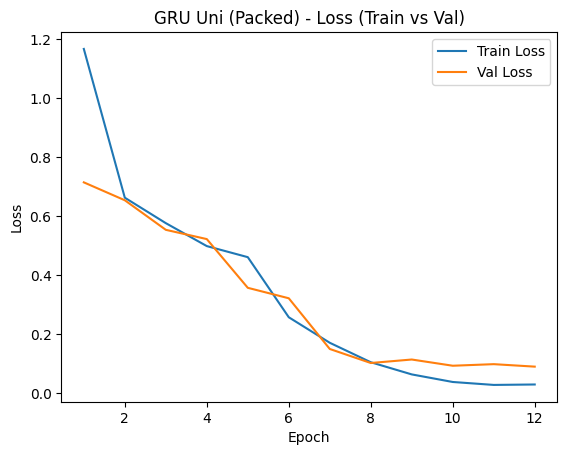

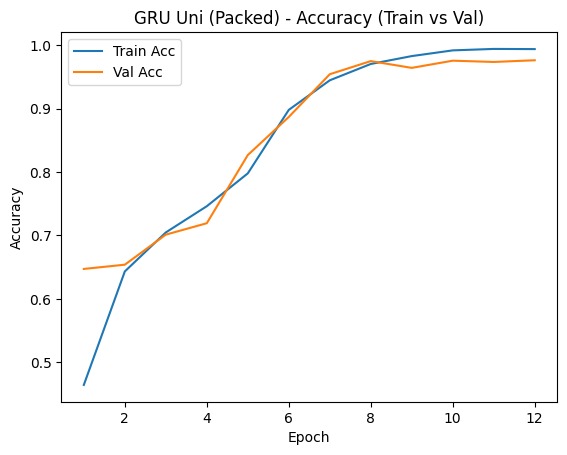

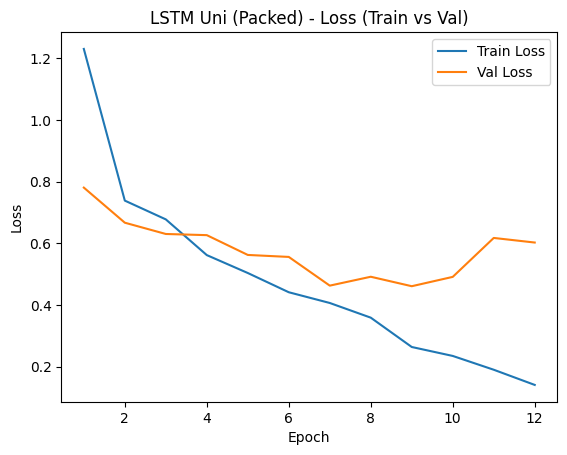

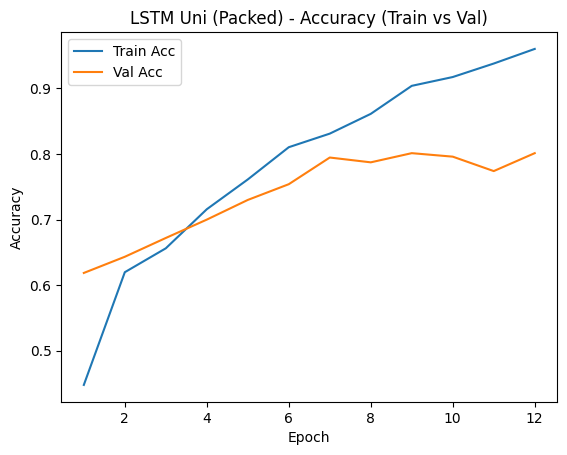

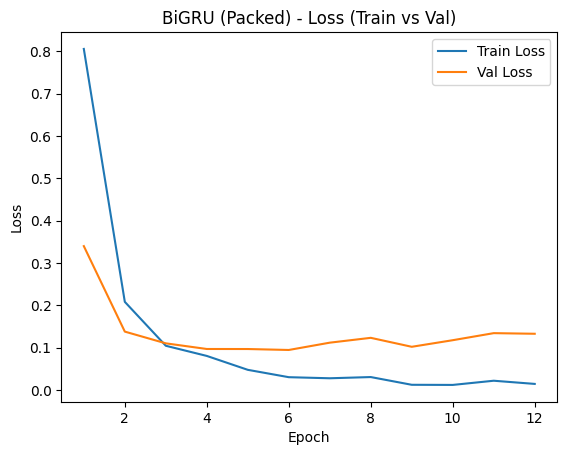

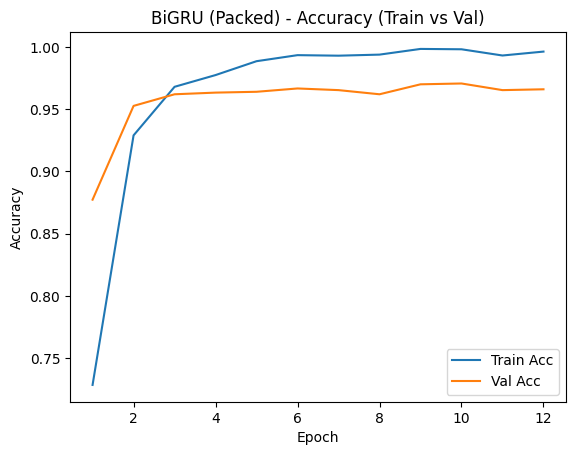

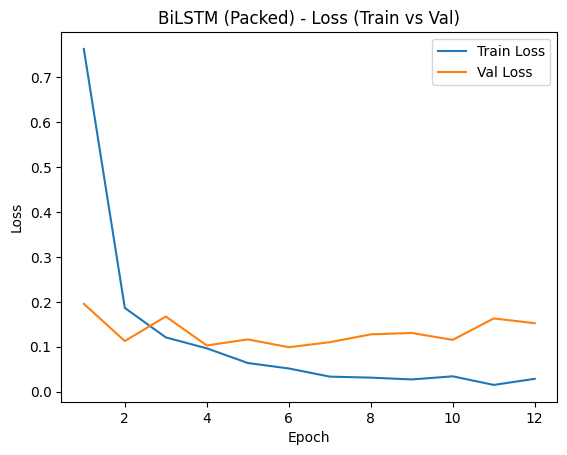

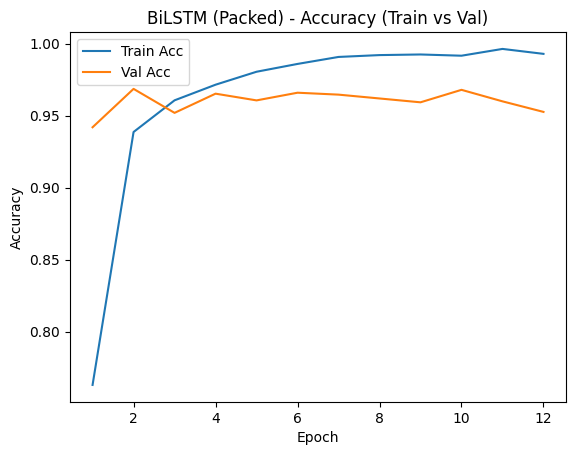

In [35]:
plot_history_torch(history_gru_tuned_pt,  "GRU Uni (Packed)")
plot_history_torch(history_lstm_tuned_pt, "LSTM Uni (Packed)")

plot_history_torch(history_bigru_tuned_pt,  "BiGRU (Packed)")
plot_history_torch(history_bilstm_tuned_pt, "BiLSTM (Packed)")

## Final Evaluation: Validation and Test + Error Analysis

This section performs a complete evaluation of the trained PyTorch packed-sequence
models on both the **validation** and **test** sets, followed by qualitative error analysis.

### Step 1: Aligning Indices for Error Analysis
The validation dataframe index is reset to ensure that prediction indices match
the corresponding text rows when displaying misclassified examples.

### Step 2: Validation Evaluation
We evaluate four models on the validation set:
- GRU (Unidirectional, Packed)
- LSTM (Unidirectional, Packed)
- BiGRU (Packed)
- BiLSTM (Packed)

Metrics reported for each model include:
- Accuracy
- Macro F1 and Weighted F1
- Confusion Matrix
- Full Classification Report

### Step 3: Test Evaluation
The same four models are evaluated on the test set to estimate final
generalization performance using identical metrics.

### Step 4: Qualitative Error Analysis
Finally, we inspect misclassifications on the validation set by printing example
reviews for confused class pairs. This helps identify systematic patterns behind
errors (e.g., ambiguous sentiment, mixed opinions, short reviews, or overlapping classes).


In [38]:
val_df = val_df.reset_index(drop=True)

# ---- Validation ----
gru_val  = evaluate_and_print_packed(model_gru_tuned_pt,  val_loader, device, "GRU Uni (Packed) - Validation")
lstm_val = evaluate_and_print_packed(model_lstm_tuned_pt, val_loader, device, "LSTM Uni (Packed) - Validation")

bigru_val  = evaluate_and_print_packed(model_bigru_tuned_pt,  val_loader, device, "BiGRU (Packed) - Validation")
bilstm_val = evaluate_and_print_packed(model_bilstm_tuned_pt, val_loader, device, "BiLSTM (Packed) - Validation")

# ---- Test ----
gru_test  = evaluate_and_print_packed(model_gru_tuned_pt,  test_loader, device, "GRU Uni (Packed) - TEST")
lstm_test = evaluate_and_print_packed(model_lstm_tuned_pt, test_loader, device, "LSTM Uni (Packed) - TEST")

bigru_test  = evaluate_and_print_packed(model_bigru_tuned_pt,  test_loader, device, "BiGRU (Packed) - TEST")
bilstm_test = evaluate_and_print_packed(model_bilstm_tuned_pt, test_loader, device, "BiLSTM (Packed) - TEST")

show_all_pair_errors_packed(
    model_gru_tuned_pt,
    val_loader,
    device,
    val_df,
    text_col="review",
    n=5
)



GRU Uni (Packed) - Validation
Accuracy: 0.9760
F1 macro: 0.9758
F1 weighted: 0.9760

Confusion Matrix:
 [[298   7   0   0   0]
 [  7 286   1   0   0]
 [  0   1 307   0   0]
 [  0   0   0 279  16]
 [  0   0   0   4 294]]

Classification Report:
               precision    recall  f1-score   support

           0     0.9770    0.9770    0.9770       305
           1     0.9728    0.9728    0.9728       294
           2     0.9968    0.9968    0.9968       308
           3     0.9859    0.9458    0.9654       295
           4     0.9484    0.9866    0.9671       298

    accuracy                         0.9760      1500
   macro avg     0.9762    0.9758    0.9758      1500
weighted avg     0.9763    0.9760    0.9760      1500


LSTM Uni (Packed) - Validation
Accuracy: 0.8013
F1 macro: 0.8000
F1 weighted: 0.8012

Confusion Matrix:
 [[231  73   1   0   0]
 [ 78 207   9   0   0]
 [  1   6 297   2   2]
 [  0   0   0 224  71]
 [  0   0   0  55 243]]

Classification Report:
               prec

In [46]:
import torch
import numpy as np
import torch.nn.functional as F
from tensorflow.keras.preprocessing.sequence import pad_sequences

# =========================
# 1) Predict single review -> rating 1..5
# =========================
@torch.no_grad()
def predict_review_rating(model, review_text, tokenizer, max_len, device):
    seq = tokenizer.texts_to_sequences([str(review_text)])
    x = pad_sequences(seq, maxlen=max_len, padding="post", truncating="post")

    x = torch.tensor(x, dtype=torch.long).to(device)
    lengths = torch.clamp((x != 0).sum(dim=1), min=1)

    model.eval()
    logits = model(x, lengths)

    probs = F.softmax(logits, dim=1).cpu().numpy()[0]   # 5 probs
    pred_class = int(np.argmax(probs))                  # 0..4
    return pred_class + 1, probs                        # 1..5

# =========================
# 2) Choose best model
# =========================
best_model = model_gru_tuned_pt   # change to model_bilstm_tuned_pt if you want
best_model.to(device)

# =========================
# 3) Put your review here
# =========================
review_text = """
I absolutely loved this product! The quality exceeded my expectations,
delivery was fast, and everything worked perfectly. Highly recommended.
"""

# =========================
# 4) Run prediction
# =========================
pred_rating, probs = predict_review_rating(best_model, review_text, tokenizer, max_len, device)

print("Review:\n", review_text.strip())
print("\nPredicted Rating:", pred_rating, "/ 5")

print("\nProbabilities:")
for i, p in enumerate(probs, start=1):
    print(f"Rating {i}: {p:.4f}")

Review:
 I absolutely loved this product! The quality exceeded my expectations,
delivery was fast, and everything worked perfectly. Highly recommended.

Predicted Rating: 5 / 5

Probabilities:
Rating 1: 0.0156
Rating 2: 0.0000
Rating 3: 0.0000
Rating 4: 0.0590
Rating 5: 0.9253
